# nano-gpt on an NVIDIA GPU (Colab launcher)

This notebook only calls the repository's own scripts. It contains no model or training code.

Before running: **Runtime > Change runtime type > GPU**.

The Colab filesystem is temporary. The last cells zip the run directory for download; nothing is kept once the runtime is recycled.

## 1. GPU and software

In [14]:
!nvidia-smi

Fri Oct  2 22:51:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [15]:
import sys
import torch

print("Python :", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
assert torch.cuda.is_available(), "No GPU: Runtime > Change runtime type > GPU"
print("GPU:", torch.cuda.get_device_name(0))
TORCH_BEFORE_INSTALL = torch.__version__

Python : 3.13.15
PyTorch: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


## 2. Clone the repository and install dependencies

Set `REF` to a commit hash for a reproducible run, or to a branch name such as `main` for the latest code.

`requirements.txt` only asks for `torch>=2.2.0`, which Colab's preinstalled CUDA build already satisfies, so pip keeps it. The last line of the cell checks this.

In [16]:
import os
import time

REPO_URL = "https://github.com/AdebanjiAdelowo/nano-gpt.git"
REF = "174c016874e3262f5679468553e2c7db3ad423d7"
REPO = "/content/nano-gpt"

# One directory per notebook session, so re-running never overwrites an earlier run.
STAMP = time.strftime("%Y%m%d-%H%M%S")
SMOKE_DIR = f"results/colab-smoke-{STAMP}"
RUN_DIR = f"results/colab-cuda-{STAMP}"

if not os.path.exists(REPO):
    !git clone {REPO_URL} {REPO}
%cd {REPO}
!git fetch -q --all && git checkout -q {REF}
!git log -1 --format='%H %ad %s' --date=short
!pip install -q -r requirements.txt
!python -c "import torch; print('PyTorch after install:', torch.__version__, '| CUDA available:', torch.cuda.is_available())"
print("PyTorch before install:", TORCH_BEFORE_INSTALL)

/content/nano-gpt
174c016874e3262f5679468553e2c7db3ad423d7 2026-10-03 Add portable device and remote GPU workflow
PyTorch after install: 2.11.0+cu130 | CUDA available: True
PyTorch before install: 2.11.0+cu130


## 3. Short CUDA smoke training (50 steps)

`--device cuda` fails with a clear error if CUDA is not available; it never falls back to CPU.

In [17]:
!python train.py --device cuda --max-iters 50 --eval-interval 25 --eval-iters 10 --out-dir {SMOKE_DIR}

Corpus: 1,115,394 chars | vocab size: 65
Parameters (non-embedding): 0.80 M  | device: cuda (requested: cuda) | out: results/colab-smoke-20261002-225102
step     0/50 │ train 4.1995 │ val 4.1993 │ lr 0.00e+00 │    0.3s
step    25/50 │ train 3.4143 │ val 3.4393 │ lr 2.50e-04 │    1.0s
step    50/50 │ train 2.8450 │ val 2.8589 │ lr 5.00e-04 │    1.5s

Training complete in 1.5s
Saved results/colab-smoke-20261002-225102/checkpoint.pt
Saved results/colab-smoke-20261002-225102/run_meta.json

── Sample output ──────────────────────────────────────────────────────

GIjam
A$
zID,in;, g dowwe s theer abld
Luan ps rlve cis, onmasthoICoin.
N?
Ave t.
Warthe
Gedother me ate cit ve oata3 tir fe vmes th liheshait  srbouitorI titees doro  the atogranw t lelao f
eron whed
───────────────────────────────────────────────────────────────────────

Saved results/colab-smoke-20261002-225102/loss_curve.png

Generate with:  python generate.py --checkpoint results/colab-smoke-20261002-225102/checkpoint.pt


In [18]:
# Gate: run_meta.json is written only after training finishes, so its presence means the smoke run succeeded.
import json
import math

smoke_meta_path = f"{SMOKE_DIR}/run_meta.json"
assert os.path.exists(smoke_meta_path), "Smoke test failed: read the error above before running the full training"
with open(smoke_meta_path) as f:
    smoke = json.load(f)
assert smoke["resolved_device"] == "cuda", smoke["resolved_device"]
assert math.isfinite(smoke["results"]["final_val_loss"]), "non-finite loss"
SMOKE_PASSED = True
print("Smoke test passed on", smoke["gpu_name"], "| val loss", round(smoke["results"]["final_val_loss"], 4))

Smoke test passed on Tesla T4 | val loss 2.8589


## 4. Normal CUDA training (default configuration, 3000 steps)

In [19]:
assert globals().get("SMOKE_PASSED"), "Run the smoke test and its check first"
!python train.py --device cuda --out-dir {RUN_DIR}

Corpus: 1,115,394 chars | vocab size: 65
Parameters (non-embedding): 0.80 M  | device: cuda (requested: cuda) | out: results/colab-cuda-20261002-225102
step     0/3000 │ train 4.1999 │ val 4.1989 │ lr 0.00e+00 │    1.4s
step   300/3000 │ train 2.3273 │ val 2.3406 │ lr 9.89e-04 │    7.6s
step   600/3000 │ train 2.0334 │ val 2.0948 │ lr 9.36e-04 │   13.4s
step   900/3000 │ train 1.8408 │ val 1.9657 │ lr 8.41e-04 │   19.9s
step  1200/3000 │ train 1.7222 │ val 1.8572 │ lr 7.17e-04 │   25.8s
step  1500/3000 │ train 1.6360 │ val 1.8097 │ lr 5.74e-04 │   32.0s
step  1800/3000 │ train 1.5842 │ val 1.7560 │ lr 4.30e-04 │   38.0s
step  2100/3000 │ train 1.5363 │ val 1.7210 │ lr 2.97e-04 │   44.2s
step  2400/3000 │ train 1.5034 │ val 1.6997 │ lr 1.92e-04 │   50.3s
step  2700/3000 │ train 1.4874 │ val 1.6816 │ lr 1.24e-04 │   56.6s
step  3000/3000 │ train 1.4741 │ val 1.6630 │ lr 1.00e-04 │   62.9s

Training complete in 62.9s
Saved results/colab-cuda-20261002-225102/checkpoint.pt
Saved results/col

## 5. Generate text from the new checkpoint

In [20]:
assert os.path.exists(f"{RUN_DIR}/run_meta.json"), "Full training did not finish: read the error above"
!python generate.py --device cuda --checkpoint {RUN_DIR}/checkpoint.pt --max_new_tokens 300 --seed 0

Loaded results/colab-cuda-20261002-225102/checkpoint.pt on cuda  │  4L · 4H · 128D  │  train loss 1.4741  │  val loss 1.6630


Put your heaven thou kinsman'd me?

ABOLTHAS:
Well not good my proud night, by to dead the see
The stone o' the shall but stone and true a in a any
Senver serval death that the paint dill
Be to like his father of your true.

ESCALUS:
Ay, my lord, why, sir, and be resifice me honour most
That bid out



## 6. Loss curve and run metadata

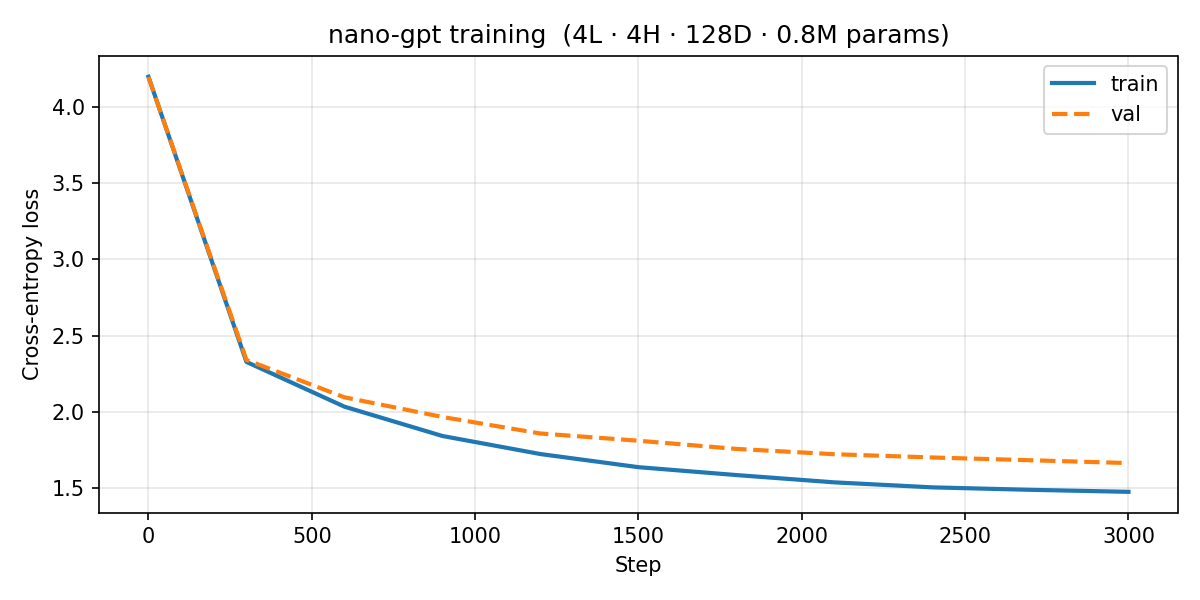

In [21]:
from IPython.display import Image, display

display(Image(filename=f"{RUN_DIR}/loss_curve.png"))

In [22]:
with open(f"{RUN_DIR}/run_meta.json") as f:
    print(json.dumps(json.load(f), indent=2))

{
  "timestamp_utc": "2026-10-02T22:52:30+00:00",
  "requested_device": "cuda",
  "resolved_device": "cuda",
  "torch_version": "2.11.0+cu130",
  "python_version": "3.13.15",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.39",
  "system": "Linux",
  "machine": "x86_64",
  "processor": "x86_64",
  "cuda_available": true,
  "cuda_version": "13.0",
  "gpu_name": "Tesla T4",
  "mps_available": false,
  "git_commit": "174c016874e3262f5679468553e2c7db3ad423d7",
  "git_dirty": false,
  "seed": 42,
  "training_config": {
    "model": {
      "block_size": 128,
      "vocab_size": 65,
      "n_layer": 4,
      "n_head": 4,
      "n_embd": 128,
      "dropout": 0.1,
      "bias": true
    },
    "batch_size": 32,
    "max_iters": 3000,
    "eval_interval": 300,
    "eval_iters": 100,
    "lr": 0.001,
    "lr_min": 0.0001,
    "warmup_iters": 100,
    "grad_clip": 1.0,
    "optimiser": "AdamW",
    "weight_decay": 0.1
  },
  "results": {
    "parameters_non_embedding": 801664,
    "total_second

## 7. Keep the results

Download the archive now, or copy it to Google Drive. It holds the checkpoints, loss curves and run metadata of both runs.

In [23]:
ARCHIVE = f"/content/nano-gpt-{os.path.basename(RUN_DIR)}.zip"
!zip -r -q {ARCHIVE} {RUN_DIR} {SMOKE_DIR}
!ls -lh {ARCHIVE}

from google.colab import files
files.download(ARCHIVE)

-rw-r--r-- 1 root root 6.0M Oct  2 22:52 /content/nano-gpt-colab-cuda-20261002-225102.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
# Optional: copy to Google Drive instead of downloading.
# from google.colab import drive
# drive.mount("/content/drive")
# !mkdir -p /content/drive/MyDrive/nano-gpt-runs && cp {ARCHIVE} /content/drive/MyDrive/nano-gpt-runs/